In [1]:
import os
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

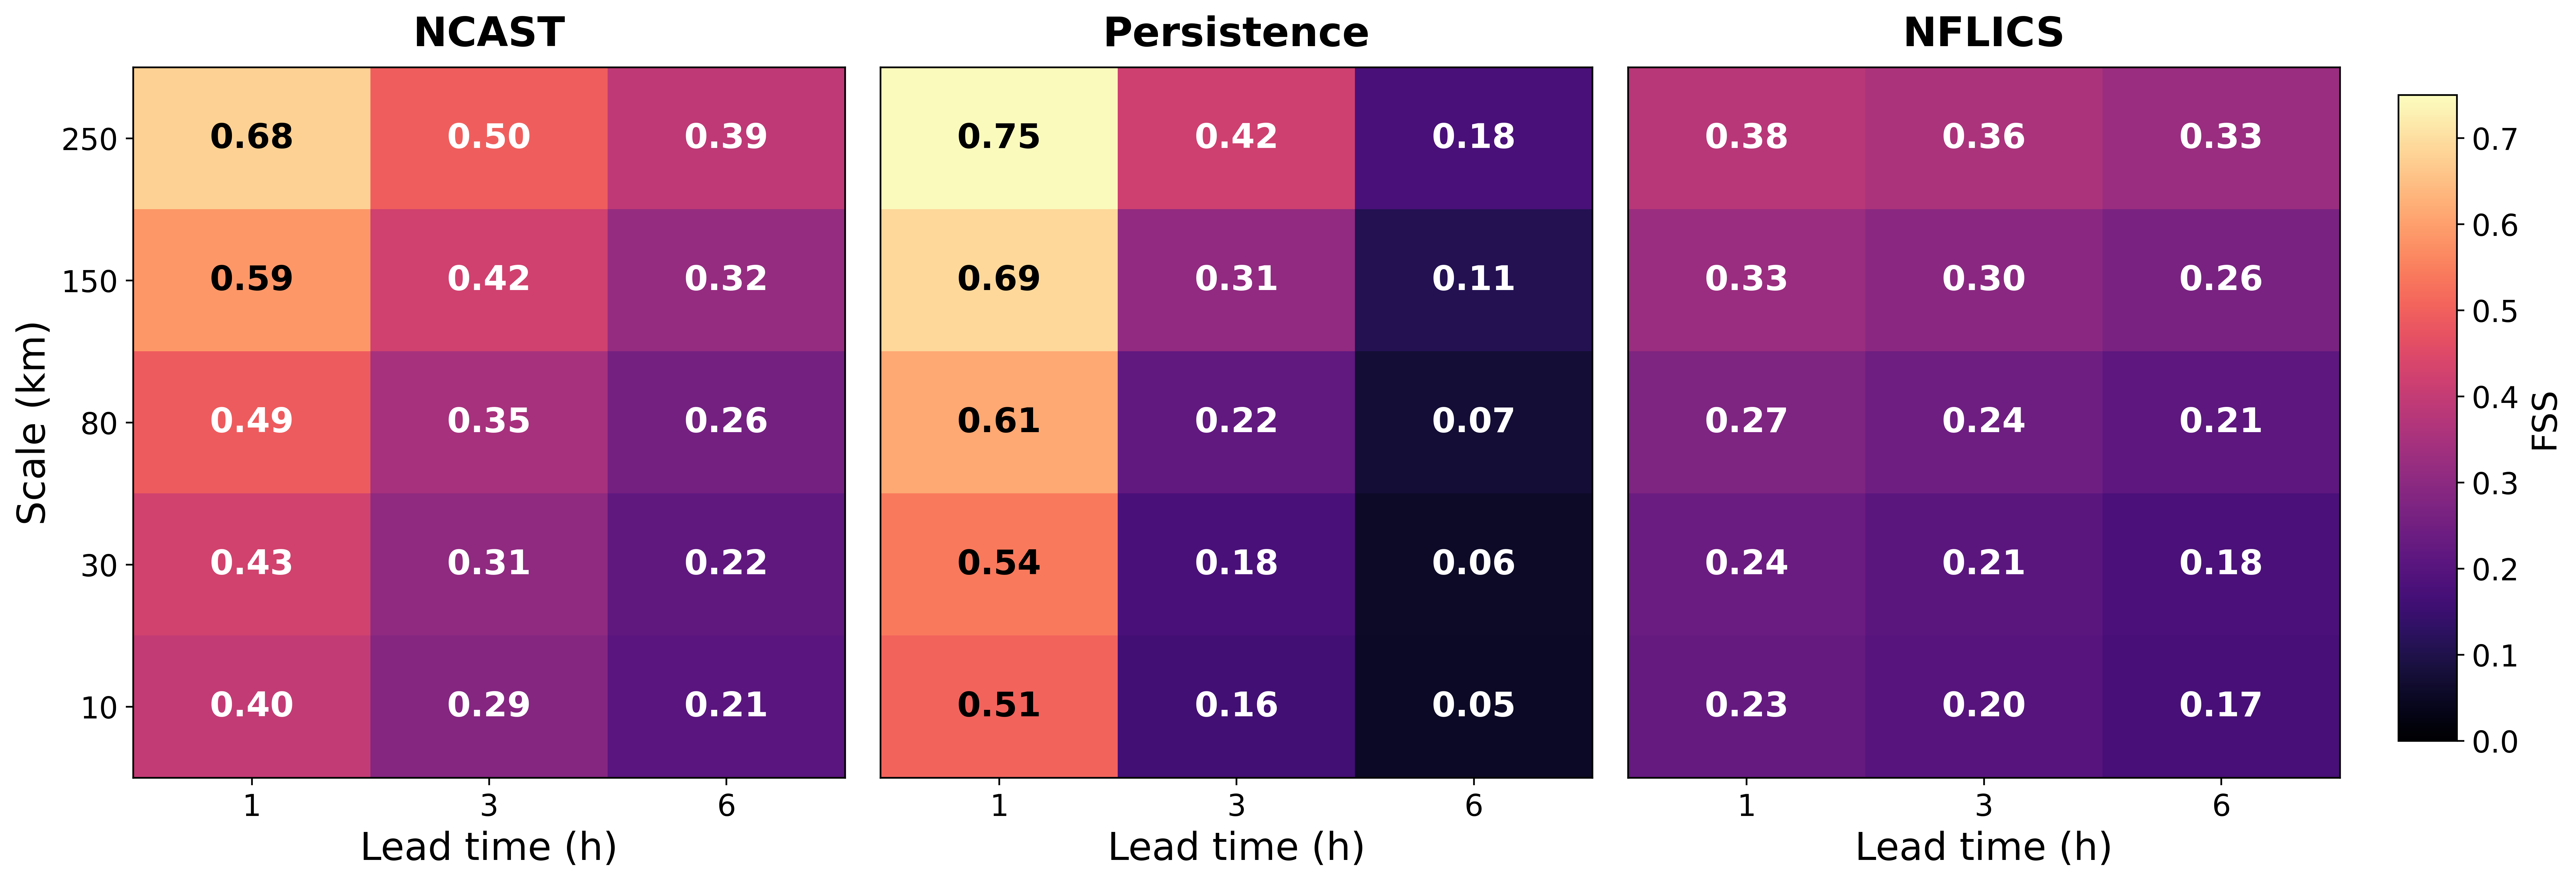

In [2]:
ens_fss_dir = "/home/users/mendrika/NCAST/Output/evaluation/ncast/fss/ensemble"
ref_fss_dir = "/home/users/mendrika/NCAST/Output/evaluation/ncast/fss/ncast-nflics"

leads = [1, 3, 6]
models = ["NCAST", "Persistence", "NFLICS"]

window_to_scale = {
    81: 250,
    49: 150,
    25: 80,
    9: 30,
    3: 10,
}

rows = []

for lead in leads:
    ens_csv = os.path.join(ens_fss_dir, f"fss_all_scenes_t{lead}.csv")
    ref_csv = os.path.join(ref_fss_dir, f"fss_all_scenes_t{lead}.csv")

    df_ens = pd.read_csv(ens_csv)
    df_ref = pd.read_csv(ref_csv)

    for window_px, scale_km in window_to_scale.items():
        ens_row = df_ens[df_ens["window_px"] == window_px].iloc[0]
        ref_row = df_ref[df_ref["window_px"] == window_px].iloc[0]

        rows.append({
            "model": "NCAST",
            "lead_time_h": lead,
            "scale_km": scale_km,
            "fss": ens_row["smooth_ensemble_mean"],
        })

        rows.append({
            "model": "Persistence",
            "lead_time_h": lead,
            "scale_km": scale_km,
            "fss": ref_row["smooth_persistence"],
        })

        rows.append({
            "model": "NFLICS",
            "lead_time_h": lead,
            "scale_km": scale_km,
            "fss": ref_row["smooth_nflics"],
        })

df_plot = pd.DataFrame(rows)

scales = [250, 150, 80, 30, 10]

fig, axes = plt.subplots(1, 3, figsize=(19, 6), dpi=500)
plt.subplots_adjust(wspace=0.05)

vmin, vmax = 0.0, 0.75
cmap = "magma"

for idx, (ax, model) in enumerate(zip(axes, models)):
    mat = np.zeros((len(scales), len(leads)))

    for i, s in enumerate(scales):
        for j, l in enumerate(leads):
            mat[i, j] = df_plot[
                (df_plot["model"] == model)
                & (df_plot["scale_km"] == s)
                & (df_plot["lead_time_h"] == l)
            ]["fss"].values[0]

    im = ax.imshow(
        mat,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        aspect="auto",
    )

    ax.set_title(model, fontsize=19, fontweight="bold", pad=10)
    ax.set_xlabel("Lead time (h)", fontsize=18)

    ax.set_xticks(range(len(leads)))
    ax.set_xticklabels(leads, fontsize=14)

    if idx == 0:
        ax.set_yticks(range(len(scales)))
        ax.set_yticklabels(scales, fontsize=14)
        ax.set_ylabel("Scale (km)", fontsize=18)
    else:
        ax.set_yticks([])

    for i in range(len(scales)):
        for j in range(len(leads)):
            v = mat[i, j]
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color="white" if v < 0.5 else "black",
            )

fig.subplots_adjust(right=0.88)

cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = plt.colorbar(im, cax=cbar_ax)
cbar.set_label("FSS", fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.show()

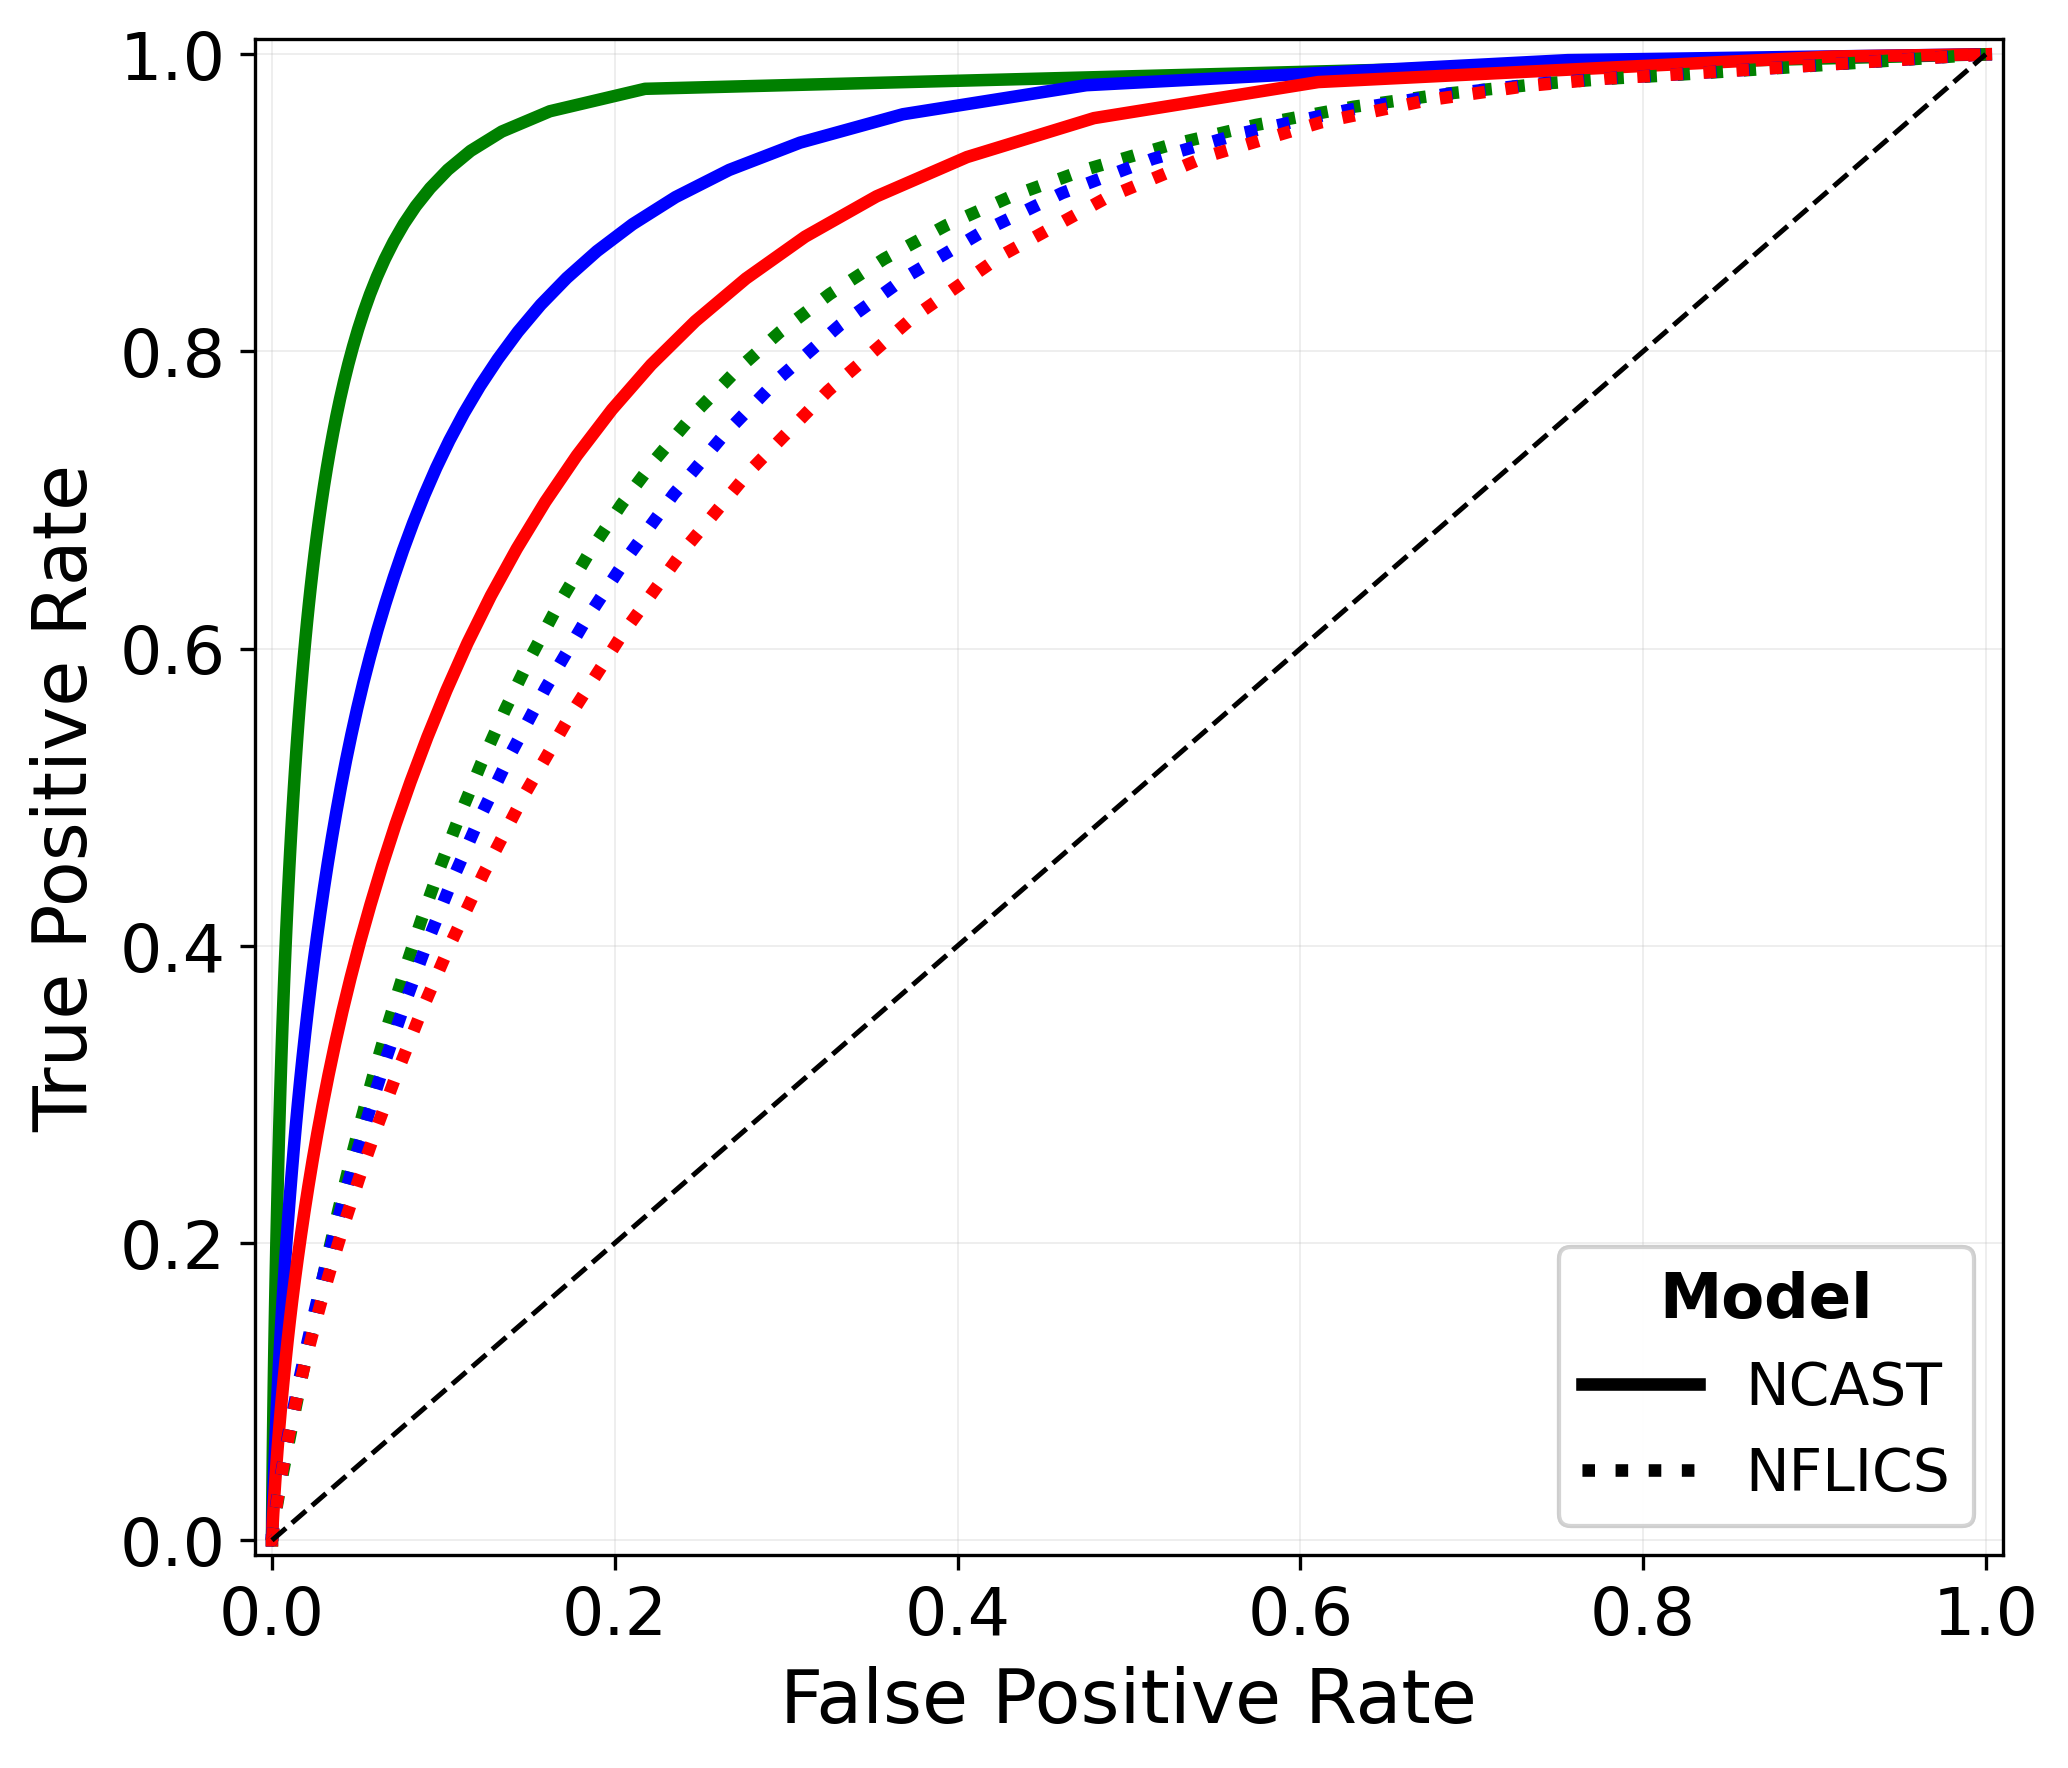

t+1 h | NCAST AUC = 0.9598 | NFLICS AUC = 0.8250
t+3 h | NCAST AUC = 0.9130 | NFLICS AUC = 0.8125
t+6 h | NCAST AUC = 0.8648 | NFLICS AUC = 0.7946


In [4]:
auc_dir = "/home/users/mendrika/NCAST/Output/evaluation/ncast/auc/ensemble"
auc_dir_nflics = "/home/users/mendrika/NCAST/Output/evaluation/ncast/auc/ncast-nflics"

leads = [1, 3, 6]
lead_colours = {
    1: "green",
    3: "blue",
    6: "red",
}

roc = {}

for lead in leads:
    fpr_model = np.load(os.path.join(auc_dir, f"roc_fpr_mean_t{lead}.npy"))
    tpr_model = np.load(os.path.join(auc_dir, f"roc_tpr_mean_t{lead}.npy"))

    fpr_nflics = np.load(os.path.join(auc_dir_nflics, f"roc_fpr_nflics_t{lead}.npy"))
    tpr_nflics = np.load(os.path.join(auc_dir_nflics, f"roc_tpr_nflics_t{lead}.npy"))

    auc_model = float(np.load(os.path.join(auc_dir, f"auc_mean_t{lead}.npy")))
    auc_nflics = float(np.load(os.path.join(auc_dir_nflics, f"auc_nflics_t{lead}.npy")))

    idx_model = np.argsort(fpr_model)
    idx_nflics = np.argsort(fpr_nflics)

    roc[lead] = {
        "fpr_ncast": fpr_model[idx_model],
        "tpr_ncast": tpr_model[idx_model],
        "fpr_nflics": fpr_nflics[idx_nflics],
        "tpr_nflics": tpr_nflics[idx_nflics],
        "auc_ncast": auc_model,
        "auc_nflics": auc_nflics,
    }

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

for lead in leads:
    ax.plot(
        roc[lead]["fpr_ncast"],
        roc[lead]["tpr_ncast"],
        color=lead_colours[lead],
        linewidth=3,
    )

for lead in leads:
    ax.plot(
        roc[lead]["fpr_nflics"],
        roc[lead]["tpr_nflics"],
        color=lead_colours[lead],
        linestyle=":",
        linewidth=3,
    )

ax.plot([0, 1], [0, 1], "k--", linewidth=1.2)

ax.set_xlabel("False Positive Rate", fontsize=18)
ax.set_ylabel("True Positive Rate", fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.grid(True, linewidth=0.1)

model_legend = ax.legend(
    handles=[
        Line2D([0], [0], color="black", lw=3, linestyle="-", label="NCAST"),
        Line2D([0], [0], color="black", lw=3, linestyle=":", label="NFLICS"),
    ],
    title="Model",
    fontsize=14,
    title_fontsize=15,
    loc="lower right",
    frameon=True,
)

model_legend.get_title().set_fontweight("bold")
ax.add_artist(model_legend)

plt.tight_layout()
plt.show()

for lead in leads:
    print(
        f"t+{lead} h | "
        f"NCAST AUC = {roc[lead]['auc_ncast']:.4f} | "
        f"NFLICS AUC = {roc[lead]['auc_nflics']:.4f}"
    )